In [30]:
from rdkit import Chem, RDLogger
from rdkit.Chem import Draw, AllChem, PandasTools, BRICS, MACCSkeys, Descriptors
from rdkit.Chem.Draw import rdMolDraw2D, SimilarityMaps
from rdkit.DataStructs.cDataStructs import TanimotoSimilarity, DiceSimilarity
from rdkit.ML.Descriptors import MoleculeDescriptors
from rdkit.Chem import Descriptors3D
import warnings


import pandas as pd
import numpy as np
from collections import Counter

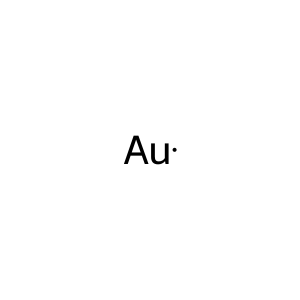

In [8]:
# for atoms
m = Chem.MolFromSmiles('[Au]')
img = Draw.MolToImage(m)
img


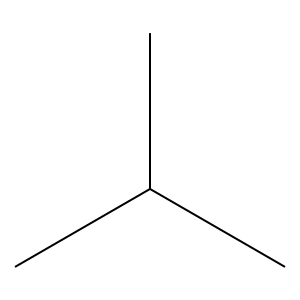

In [7]:
# for alkyl chains
m = Chem.MolFromSmiles('CC(C)C')
img = Draw.MolToImage(m)
img

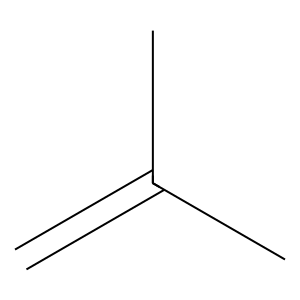

In [9]:

# for alkenes
m = Chem.MolFromSmiles('C=C(C)C')
img = Draw.MolToImage(m)
img

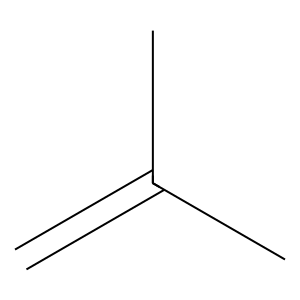

In [10]:
# for alkenes
m = Chem.MolFromSmiles('C=C(C)C')
img = Draw.MolToImage(m)
img

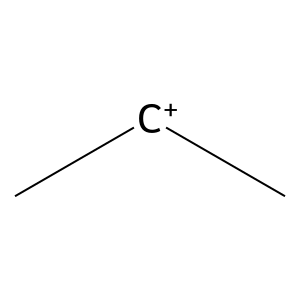

In [11]:
# for charged species
m = Chem.MolFromSmiles('C[CH+]C')
img = Draw.MolToImage(m)
img

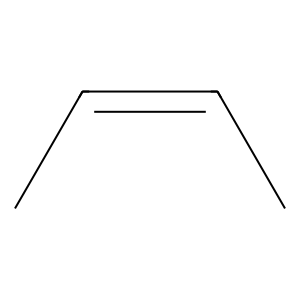

In [12]:
# for cis/trans compounds
m = Chem.MolFromSmiles('C\C=C/C')
img = Draw.MolToImage(m)
img

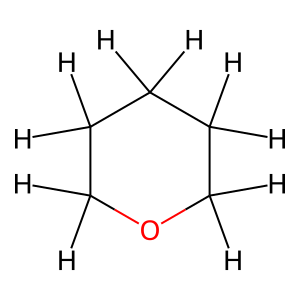

In [29]:
# for cyclic compounds
m = Chem.MolFromSmiles('C3CCCCO3')
m = Chem.AddHs(m) #HYDROGEN
img = Draw.MolToImage(m)
img

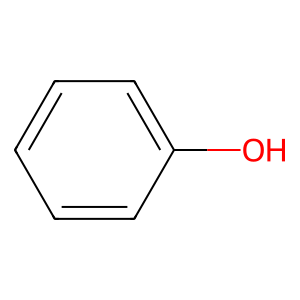

In [14]:
# for aromatic systems
m = Chem.MolFromSmiles('c1ccccc1O')
img = Draw.MolToImage(m)
img

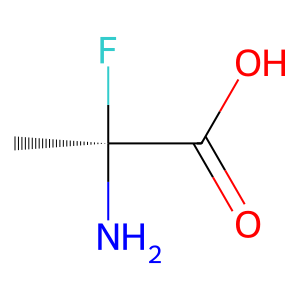

In [15]:
# for steroisomers
m = Chem.MolFromSmiles('N[C@@](C)(F)C(=O)O')
img = Draw.MolToImage(m)
img

In [23]:
df = pd.read_excel('smiles.xlsx')

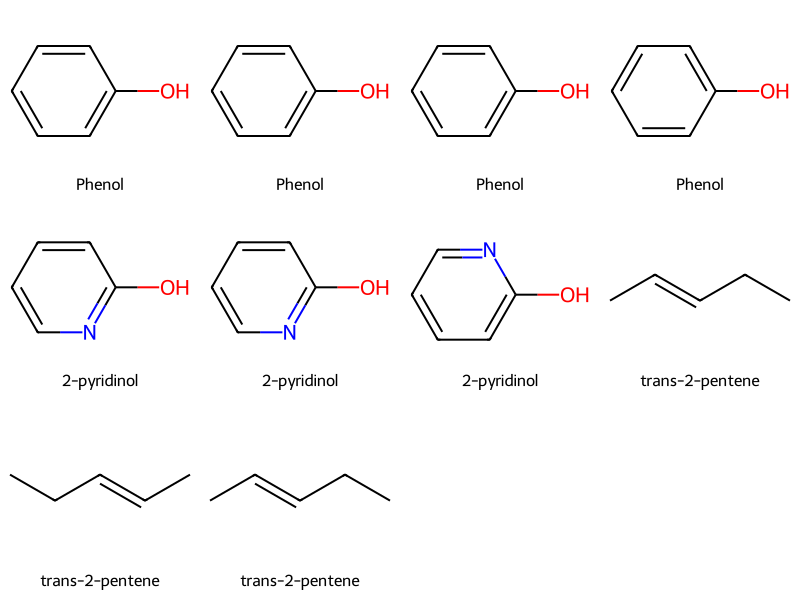

In [26]:
mols = [Chem.MolFromSmiles(smile) for smile in df['Smiles']]
img=Draw.MolsToGridImage(mols,molsPerRow=4,subImgSize=(200,200),legends=[name for name in df['Name']])
img

In [28]:
unique_smiles = [] #Empty list

for smile in df['Smiles']:
    mol = Chem.MolFromSmiles(smile)
    unique_smiles.append(Chem.MolToSmiles(mol))

df['unique_smiles'] = unique_smiles
df.drop_duplicates(subset=['unique_smiles'], inplace=True)


df.drop('Smiles', axis=1, inplace=True)

df

,Name,unique_smiles
0,Phenol,Oc1ccccc1
4,2-pyridinol,Oc1ccccn1
7,trans-2-pentene,C/C=C/CC


In [ ]:
SDF = PandasTools.LoadSDF('molecule.sdf',
                            smilesName='SMILES',
                            molColName='Molecule',
                            )